# Nettoyage et préparation des données
Objectif : rendre le jeu de données `Food delivery.csv` exploitable pour prédire `Delivery_Time_min`. Chaque décision de nettoyage est justifiée.

## 1. Importation des packages
Import de pandas et numpy (manipulation des données), matplotlib et seaborn (visualisation).

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from deliveryeta.paths import DELIVERY_DATA_B , DELIVERY_DATA_S

## 2. Chargement du fichier 
Chargement du fichier brut depuis `data/bronze/`. Le fichier original n'est jamais modifié ; les données nettoyées seront sauvegardées dans `data/silver/`.

In [2]:
df = pd.read_csv(DELIVERY_DATA_B)

## 3. Informations générales sur le jeu de données
Le jeu contient 1000 lignes et 9 colonnes. `info()` montre les types et les valeurs non nulles de chaque colonne.

In [3]:
print("\n-----------------------------------------------------------\n")
print("DataFrame Shape: ")
print("\n-----------------------------------------------------------\n")
df.info()
print("\n-----------------------------------------------------------\n")
df.describe()


-----------------------------------------------------------

DataFrame Shape: 

-----------------------------------------------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB

-----------------------------------------------------------



,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


## 4. Noms des colonnes
Liste des colonnes : identifiant, variables explicatives et variable cible `Delivery_Time_min`.

In [4]:
roles = {c: "Variable explicative" for c in df.columns}
roles["Order_ID"] = "Identifiant"
roles["Delivery_Time_min"] = "Variable cible"

columns_table = pd.DataFrame({
    "Colonne": df.columns,
    "Rôle": [roles[c] for c in df.columns],
    "Type": df.dtypes.values
})
columns_table

,Colonne,Rôle,Type
0,Order_ID,Identifiant,int64
1,Distance_km,Variable explicative,float64
2,Weather,Variable explicative,object
3,Traffic_Level,Variable explicative,object
4,Time_of_Day,Variable explicative,object
5,Vehicle_Type,Variable explicative,object
6,Preparation_Time_min,Variable explicative,int64
7,Courier_Experience_yrs,Variable explicative,float64
8,Delivery_Time_min,Variable cible,int64


## 5. Dataset Sample
Aperçu des premières lignes pour vérifier le format des valeurs.

In [5]:
df.sample(5 , random_state=43)

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
858,490,17.86,Clear,Low,Afternoon,Scooter,16,8.0,83
986,459,1.60,Clear,Medium,Evening,Bike,14,8.0,24
183,527,8.59,Clear,Low,Night,Scooter,17,8.0,36
502,396,18.65,Foggy,Low,Night,Car,19,2.0,68
710,740,7.85,Clear,Low,Afternoon,Scooter,7,9.0,34


## 6. Types de données
Les colonnes numériques et catégorielles ont déjà le bon type :
- `int64` : `Order_ID`, `Preparation_Time_min`, `Delivery_Time_min`
- `float64` : `Distance_km`, `Courier_Experience_yrs`
- `object` (texte) : `Weather`, `Traffic_Level`, `Time_of_Day`, `Vehicle_Type`

**Conclusion :** aucune conversion de type n'est nécessaire. Les variables catégorielles restent en `object` et seront encodées à l'étape de modélisation. `Order_ID` est un identifiant : il sera exclu des variables explicatives.

In [6]:
df.dtypes

Order_ID                    int64
Distance_km               float64
Weather                    object
Traffic_Level              object
Time_of_Day                object
Vehicle_Type               object
Preparation_Time_min        int64
Courier_Experience_yrs    float64
Delivery_Time_min           int64
dtype: object

## 7. Séparation des variables
Séparation en variables numériques (`Distance_km`, `Preparation_Time_min`, `Courier_Experience_yrs`, `Delivery_Time_min`) et catégorielles (`Weather`, `Traffic_Level`, `Time_of_Day`, `Vehicle_Type`). `Order_ID` est un simple identifiant, non utilisé pour la prédiction.

In [7]:
id_col = "Order_ID"
num_cols = df.select_dtypes(include="number").columns.drop(id_col).tolist()
cat_cols = df.select_dtypes(include="object").columns.tolist()

print("Variables numériques :", num_cols)
print('\n---------------------------------------------------------\n')
print("Variables catégorielles :", cat_cols)

Variables numériques : ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs', 'Delivery_Time_min']

---------------------------------------------------------

Variables catégorielles : ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']


## 8. Valeurs uniques
Liste des modalités de chaque variable catégorielle pour détecter les incohérences (espaces, majuscules/minuscules). [Résultat : à compléter]

In [8]:
for col in cat_cols :
    print(col ,'Unique value is : \n' , df[col].unique(),'\n')

Weather Unique value is : 
 ['Windy' 'Clear' 'Foggy' 'Rainy' 'Snowy' nan] 

Traffic_Level Unique value is : 
 ['Low' 'Medium' 'High' nan] 

Time_of_Day Unique value is : 
 ['Afternoon' 'Evening' 'Night' 'Morning' nan] 

Vehicle_Type Unique value is : 
 ['Scooter' 'Bike' 'Car'] 



## 9. Nombre de valeurs uniques par colonne
Permet de distinguer les variables à peu de modalités (catégorielles) des variables continues.

In [9]:
print(df.nunique().sort_values(ascending=False))

Order_ID                  1000
Distance_km                785
Delivery_Time_min          108
Preparation_Time_min        25
Courier_Experience_yrs      10
Weather                      5
Time_of_Day                  4
Traffic_Level                3
Vehicle_Type                 3
dtype: int64


## 10. Résumé initial du jeu de données
Statistiques descriptives (`describe()`). Aucune valeur négative ou nulle impossible dans `Distance_km` et `Preparation_Time_min`. [Autres remarques : à compléter]

In [10]:
statistique = pd.DataFrame({
    'DataType' : df.dtypes ,
    'NonNull' : df.notna().sum(),
    'NullValue' : df.isna().sum(),
    'Unique' : df.nunique()
})
statistique

,DataType,NonNull,NullValue,Unique
Order_ID,int64,1000,0,1000
Distance_km,float64,1000,0,785
Weather,object,970,30,5
Traffic_Level,object,970,30,3
Time_of_Day,object,970,30,4
Vehicle_Type,object,1000,0,3
Preparation_Time_min,int64,1000,0,25
Courier_Experience_yrs,float64,970,30,10
Delivery_Time_min,int64,1000,0,108


## 11. Analyse des valeurs manquantes
Quatre colonnes contiennent des valeurs manquantes : `Weather`, `Traffic_Level`, `Time_of_Day` et `Courier_Experience_yrs`.
### 11.1 Comptage des valeurs manquantes
30 valeurs manquantes dans chacune des 4 colonnes.

In [11]:
count_nun = df.isna().sum()
count_nun[count_nun > 0]

Weather                   30
Traffic_Level             30
Time_of_Day               30
Courier_Experience_yrs    30
dtype: int64

### 11.2 Pourcentage de valeurs manquantes
Chaque colonne concernée a 3 % de valeurs manquantes : un taux faible, la suppression des lignes est possible mais fait perdre de l'information inutilement.

In [12]:
nun_per = (df.isna().mean() * 100)
nun_per[nun_per > 0]

Weather                   3.0
Traffic_Level             3.0
Time_of_Day               3.0
Courier_Experience_yrs    3.0
dtype: float64

### 11.3 Visualisation des distributions numériques
Histogrammes de `Courier_Experience_yrs` pour observer la forme de la distribution. [Observation : à compléter]

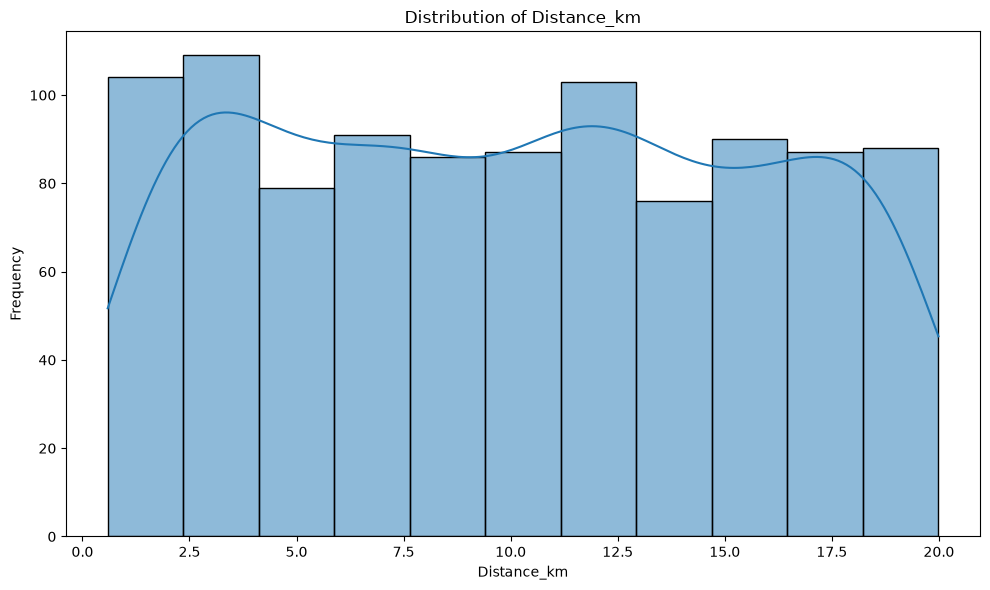

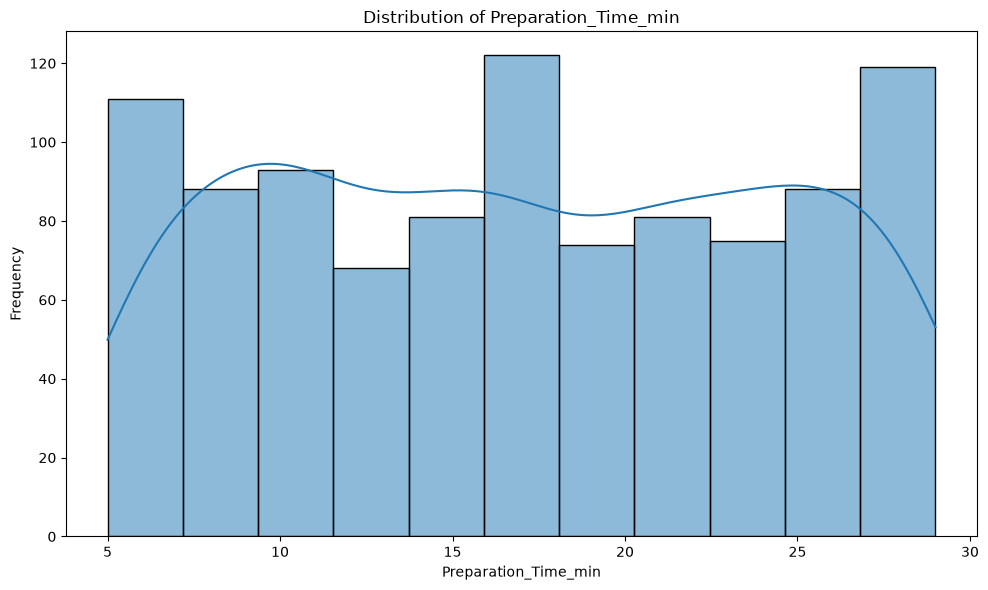

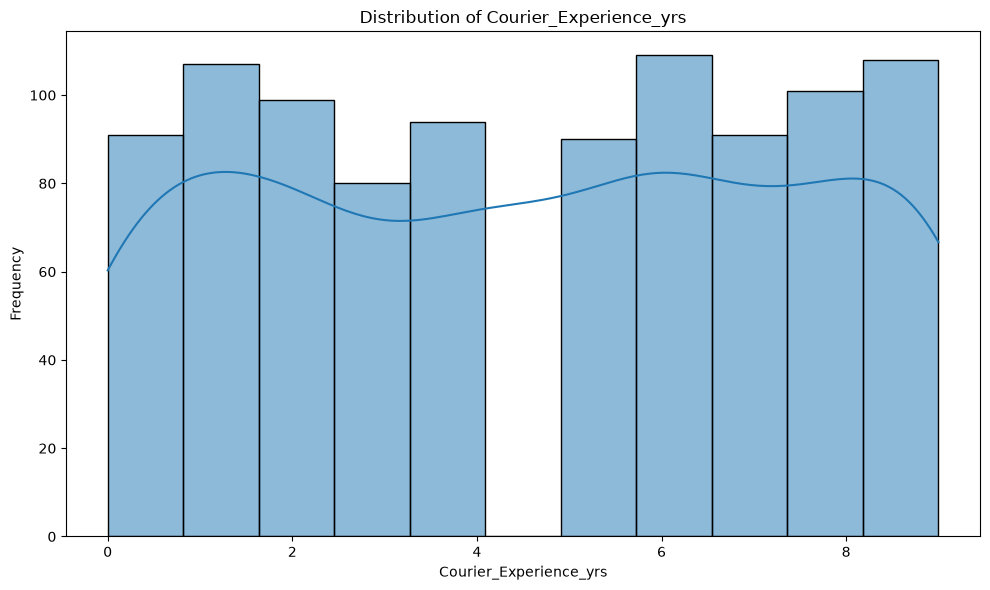

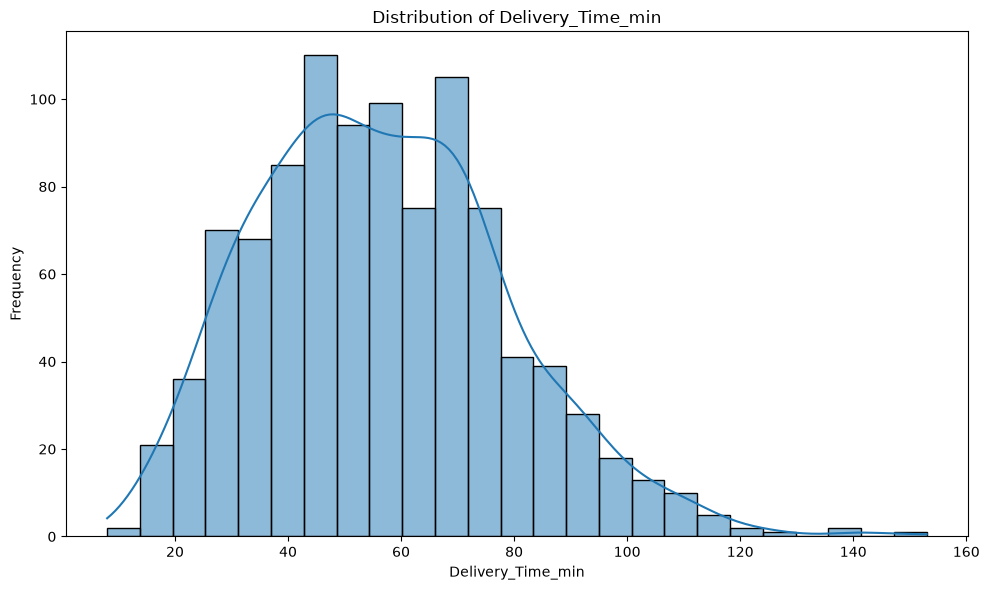

In [13]:
for col in num_cols :
    plt.figure(figsize=(10 , 6))
    sns.histplot(data=df , x=col , kde=True)
    plt.title(f'Distribution of {col}')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

### 11.4 Analyse à l'aide de boxplots
Les boxplots montrent la présence éventuelle de valeurs extrêmes qui influenceraient la moyenne. [Observation : à compléter]

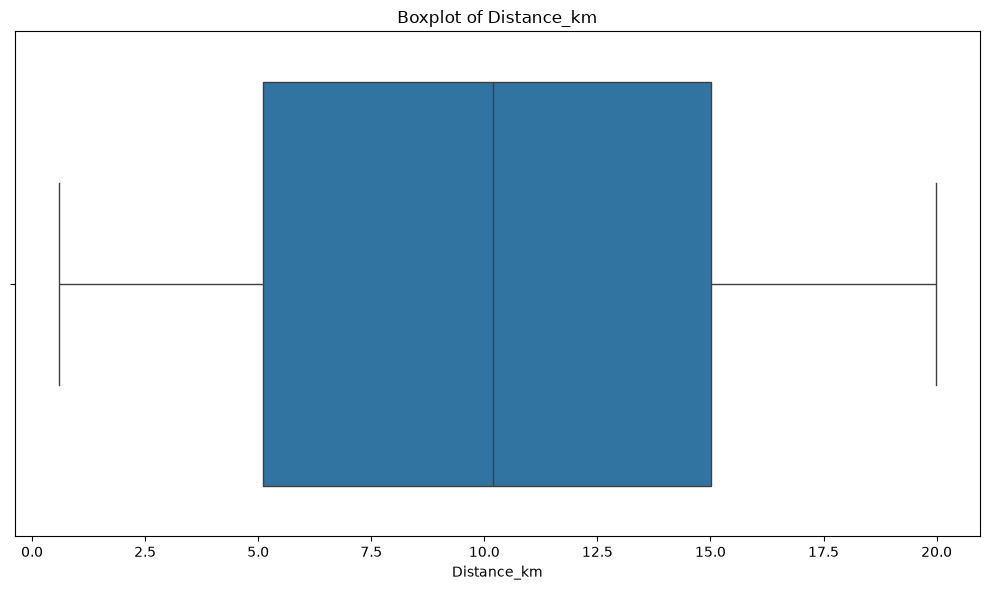

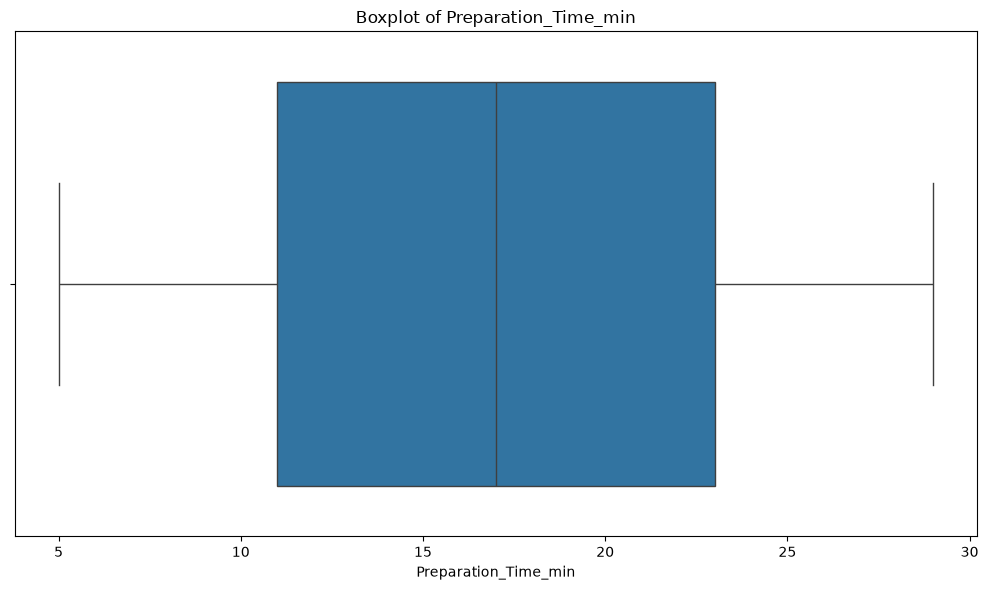

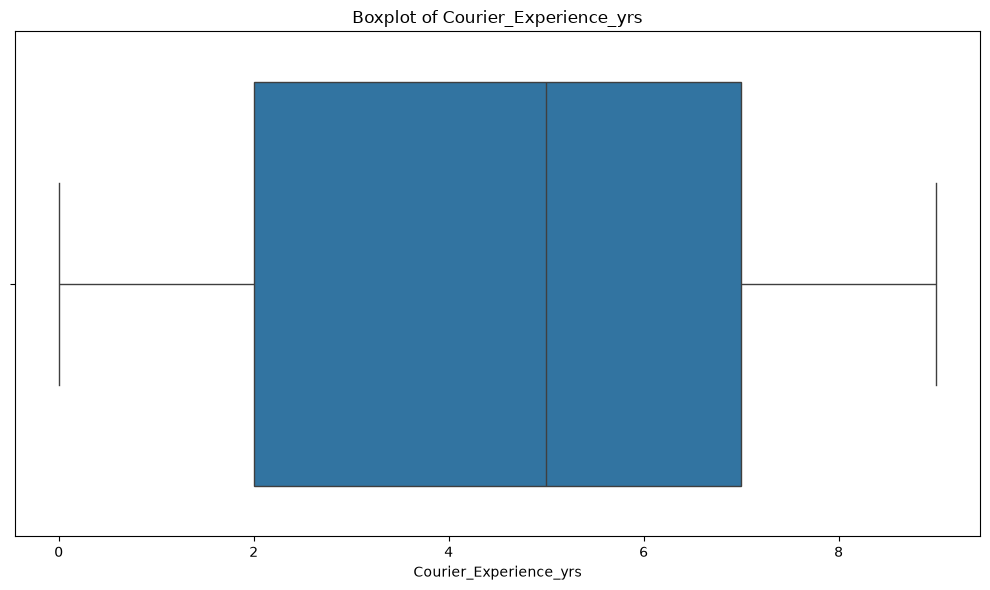

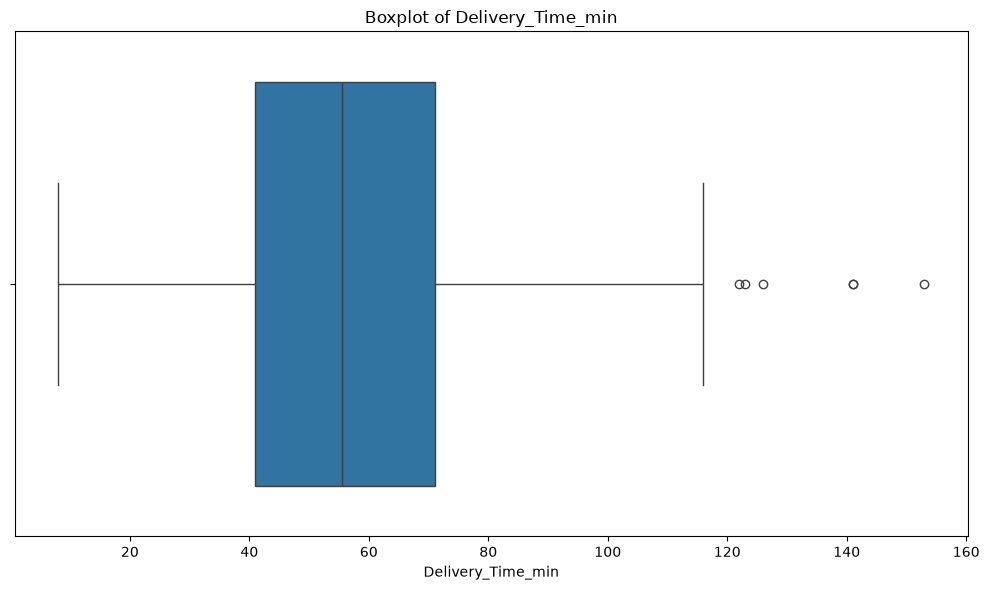

In [14]:
for col in num_cols :
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x=col)
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()

### 11.5 Calcul de l'asymétrie
Le coefficient d'asymétrie (`skew()`) indique si la distribution est symétrique. [Valeur : à compléter]
`Distance_km` (0,04), `Preparation_Time_min` (0,03) et `Courier_Experience_yrs` (-0,03) ont un coefficient d'asymétrie proche de 0 : leurs distributions sont symétriques. `Delivery_Time_min` (0,51) est légèrement asymétrique à droite, à cause de quelques livraisons très longues.

In [15]:
df[num_cols].skew()

Distance_km               0.038840
Preparation_Time_min      0.030008
Courier_Experience_yrs   -0.029087
Delivery_Time_min         0.507251
dtype: float64

### 11.6 Comparaison de la moyenne et de la médiane
Si la moyenne et la médiane sont proches, la distribution est symétrique ; sinon la médiane est plus robuste. [Résultat : à compléter]

In [16]:
desc = pd.DataFrame({
    "mean": df[num_cols].mean(),
    "median": df[num_cols].median(),
    "std_dev": df[num_cols].std(),
    "variance": df[num_cols].var(),
    "skewness": df[num_cols].skew(),
    "min": df[num_cols].min(),
    "max": df[num_cols].max(),
    "25%": df[num_cols].quantile(0.25),
    "50%": df[num_cols].quantile(0.5),
    "75%": df[num_cols].quantile(0.75)
})

desc

,mean,median,std_dev,variance,skewness,min,max,25%,50%,75%
Distance_km,10.059970,10.19,5.696656,32.451884,0.038840,0.59,19.99,5.105,10.19,15.0175
Preparation_Time_min,16.982000,17.00,7.204553,51.905582,0.030008,5.00,29.00,11.000,17.00,23.0000
Courier_Experience_yrs,4.579381,5.00,2.914394,8.493692,-0.029087,0.00,9.00,2.000,5.00,7.0000
Delivery_Time_min,56.732000,55.50,22.070915,487.125301,0.507251,8.00,153.00,41.000,55.50,71.0000


### 11.7 Distribution des valeurs manquantes catégorielles
Fréquence de chaque modalité pour `Weather`, `Traffic_Level` et `Time_of_Day`, afin d'identifier le mode.

In [17]:
for col in cat_cols :
    print(f'Value counts for column {col} :\n')
    print(df[col].value_counts(dropna=False))
    print(f'Mode : {df[col].mode()[0]}\n')

Value counts for column Weather :

Weather
Clear    470
Rainy    204
Foggy    103
Snowy     97
Windy     96
NaN       30
Name: count, dtype: int64
Mode : Clear

Value counts for column Traffic_Level :

Traffic_Level
Medium    390
Low       383
High      197
NaN        30
Name: count, dtype: int64
Mode : Medium

Value counts for column Time_of_Day :

Time_of_Day
Morning      308
Evening      293
Afternoon    284
Night         85
NaN           30
Name: count, dtype: int64
Mode : Morning

Value counts for column Vehicle_Type :

Vehicle_Type
Bike       503
Scooter    302
Car        195
Name: count, dtype: int64
Mode : Bike



### 11.7 Conclusion et stratégie d’imputation

L’analyse des valeurs manquantes montre que quatre variables présentent des données manquantes : `Weather`, `Traffic_Level`, `Time_of_Day` et `Courier_Experience_yrs`. Chaque variable contient 30 valeurs manquantes, soit **3 % du jeu de données**. Cette proportion reste faible et ne justifie pas la suppression des lignes concernées, car cette opération entraînerait une perte de 3 % des observations pour chacune de ces variables.

La stratégie d’imputation est déterminée en fonction du **type de variable** et, pour la variable numérique, de la **forme de sa distribution**.

#### 1. `Courier_Experience_yrs`

Cette variable est numérique et contient 30 valeurs manquantes, soit 3 % des observations.

L'analyse de sa distribution montre :

* moyenne : **4,58 ans**
* médiane : **5,00 ans**
* écart-type : **2,91**
* asymétrie (`skewness`) : **-0,029**
* minimum : **0 an**
* maximum : **9 ans**

Le coefficient d'asymétrie est très proche de zéro (`-0,029`), ce qui indique que la distribution est **approximativement symétrique**. De plus, la moyenne (**4,58**) et la médiane (**5,00**) sont relativement proches. Le boxplot ne montre pas de valeurs extrêmes suffisamment importantes pour justifier l'utilisation systématique de la médiane.

Par conséquent, la **moyenne** est retenue pour remplacer les valeurs manquantes de `Courier_Experience_yrs`.

La valeur d'imputation sera donc :

**4,58 ans environ.**

Cette décision permet de conserver la tendance centrale de la distribution tout en évitant de supprimer les observations concernées.

```python
df["Courier_Experience_yrs"] = df["Courier_Experience_yrs"].fillna(
    df["Courier_Experience_yrs"].mean()
)
```

---

#### 2. `Weather`

`Weather` est une variable catégorielle contenant 30 valeurs manquantes, soit 3 % des observations.

Les modalités observées sont :

* `Windy`
* `Clear`
* `Foggy`
* `Rainy`
* `Snowy`

Une moyenne ou une médiane ne peut pas être utilisée pour une variable catégorielle. L'imputation doit donc être réalisée à partir d'une modalité existante.

La stratégie retenue est l'utilisation de la **mode**, c'est-à-dire la catégorie la plus fréquente dans la variable. Cette méthode permet de remplacer les valeurs manquantes par une modalité déjà présente dans les données sans créer une nouvelle catégorie artificielle.

```python
df["Weather"] = df["Weather"].fillna(
    df["Weather"].mode()[0]
)
```

La modalité utilisée sera déterminée automatiquement à partir de la fréquence observée dans le jeu de données.

---

#### 3. `Traffic_Level`

`Traffic_Level` est une variable catégorielle contenant également **30 valeurs manquantes, soit 3 %**.

Les modalités observées sont :

* `Low`
* `Medium`
* `High`

Comme pour `Weather`, les mesures statistiques telles que la moyenne et la médiane ne sont pas adaptées à une variable catégorielle.

La **mode** sera donc utilisée afin de remplacer les valeurs manquantes par le niveau de trafic le plus fréquent dans le jeu de données.

```python
df["Traffic_Level"] = df["Traffic_Level"].fillna(
    df["Traffic_Level"].mode()[0]
)
```

Cette stratégie permet de conserver une modalité cohérente avec les données réellement observées.

---

#### 4. `Time_of_Day`

`Time_of_Day` contient **30 valeurs manquantes, soit 3 %** des observations.

Les modalités observées sont :

* `Morning`
* `Afternoon`
* `Evening`
* `Night`

Il s'agit également d'une variable catégorielle. La moyenne et la médiane ne sont donc pas pertinentes.

La **mode** sera utilisée pour remplacer les valeurs manquantes, car elle correspond à la période de la journée la plus représentée dans le jeu de données.

```python
df["Time_of_Day"] = df["Time_of_Day"].fillna(
    df["Time_of_Day"].mode()[0]
)
```

---

### Synthèse de la stratégie d'imputation

| Variable                 | Type         | Valeurs manquantes | Pourcentage | Analyse                                                                         | Méthode retenue |
| ------------------------ | ------------ | -----------------: | ----------: | ------------------------------------------------------------------------------- | --------------- |
| `Courier_Experience_yrs` | Numérique    |                 30 |         3 % | Distribution approximativement symétrique, skewness = -0,029, moyenne ≈ médiane | **Moyenne**     |
| `Weather`                | Catégorielle |                 30 |         3 % | Variable qualitative                                                            | **Mode**        |
| `Traffic_Level`          | Catégorielle |                 30 |         3 % | Variable qualitative                                                            | **Mode**        |
| `Time_of_Day`            | Catégorielle |                 30 |         3 % | Variable qualitative                                                            | **Mode**        |

## 12. Analyse des doublons
Les doublons faussent l'apprentissage en donnant plus de poids à certaines observations.

### 12.1 Nombre de lignes dupliquées
[Nombre de lignes entièrement identiques : à compléter]

In [18]:
print("\n-----------------------------------------------------------\n")

dup_count = df.duplicated().sum()
print(f"Number of duplicate rows in the DataFrame: {dup_count}")

dup_percentage = (dup_count / len(df)) * 100
print(f"Percentage of duplicate rows in the DataFrame: {dup_percentage:.2f}%")


-----------------------------------------------------------

Number of duplicate rows in the DataFrame: 0
Percentage of duplicate rows in the DataFrame: 0.00%


### 12.2 Visualiser les doublons
Affichage des lignes dupliquées s'il y en a. [Observation : à compléter]

In [19]:
dup = df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())
dup

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min


### 12.3 Important : lignes dupliquées vs Order_ID dupliqués
Une ligne dupliquée est identique sur toutes les colonnes ; un `Order_ID` dupliqué peut cacher une même commande enregistrée deux fois avec des valeurs différentes. [Résultat : à compléter]

In [20]:
order_id_dupl = df[df.duplicated(subset=["Order_ID"], keep=False)].sort_values(by="Order_ID")
order_id_dupl

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min


## 12.4 Conclusion sur les doublons

L'analyse des doublons montre qu'aucune ligne entièrement dupliquée n'est présente dans le jeu de données.

Le nombre de lignes dupliquées est de **0**, soit **0 % des 1 000 observations**. Il n'est donc pas nécessaire de supprimer des lignes pour cette raison.

Une deuxième vérification a été effectuée sur la colonne `Order_ID` afin de détecter d'éventuels identifiants de commande dupliqués. Aucun `Order_ID` dupliqué n'a été détecté.

Ainsi, le jeu de données ne présente **aucun doublon au niveau des observations ni au niveau des identifiants de commande**.

**Décision : aucune suppression de ligne n'est nécessaire concernant les doublons.**

# 13. Analyse des valeurs aberrantes

L’analyse des valeurs aberrantes porte sur la variable numérique `Courier_Experience_yrs`. Elle combine une visualisation par boxplot et la méthode de l’écart interquartile (IQR).

## 13.1 Boxplots

Le boxplot permet d’identifier visuellement les valeurs qui s’éloignent de la distribution principale.

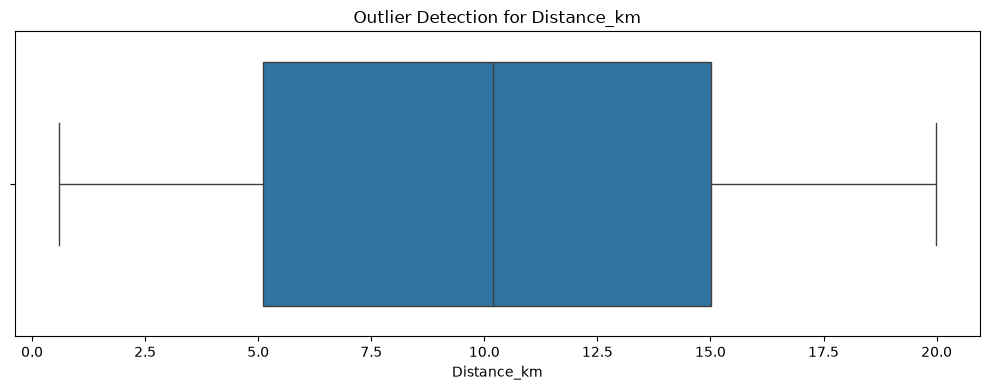

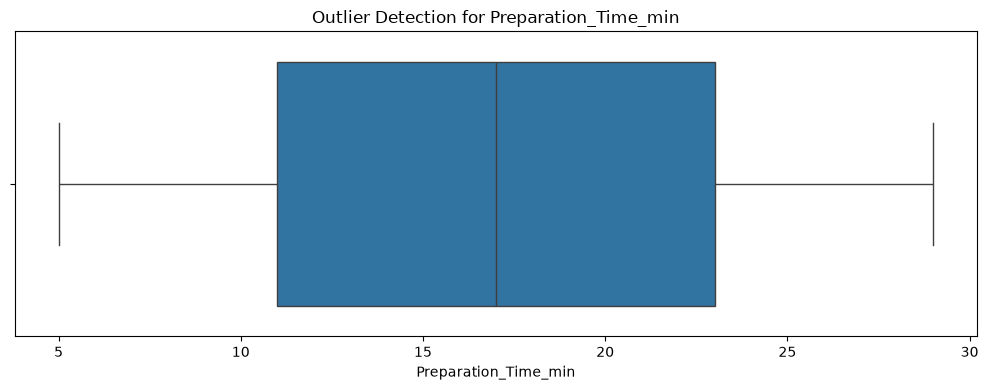

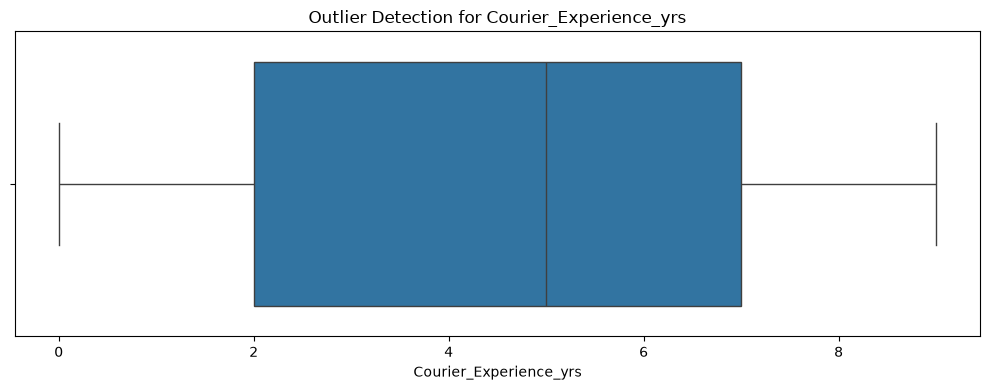

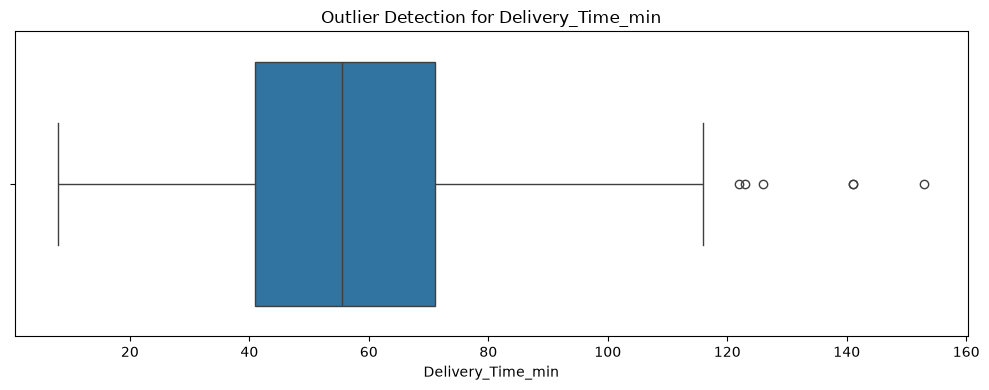

In [21]:
for col in num_cols:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Outlier Detection for {col}")
    plt.tight_layout()
    plt.show()

## 13.2 Méthode de l’IQR

La méthode de l’IQR identifie comme aberrantes les valeurs situées en dehors des bornes suivantes :

- Borne inférieure : `Q1 - 1,5 × IQR`
- Borne supérieure : `Q3 + 1,5 × IQR`

In [22]:
outlier_summary = []

for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    
    IQR = q3 - q1
    
    lower_bound = q1 - 1.5 * IQR
    upper_bound = q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    outlier_summary.append({
        "column": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Number of Outliers": len(outliers),
        "Outliers Percentage": (len(outliers) / len(df)) * 100
    })
    
outlier_summary_df = pd.DataFrame(outlier_summary)
outlier_summary_df

,column,Q1,Q3,IQR,Lower Bound,Upper Bound,Number of Outliers,Outliers Percentage
0,Distance_km,5.105,15.0175,9.9125,-9.76375,29.88625,0,0.0
1,Preparation_Time_min,11.000,23.0000,12.0000,-7.00000,41.00000,0,0.0
2,Courier_Experience_yrs,2.000,7.0000,5.0000,-5.50000,14.50000,0,0.0
3,Delivery_Time_min,41.000,71.0000,30.0000,-4.00000,116.00000,6,0.6


## 13.3 Identification des valeurs aberrantes

La méthode de l’IQR a identifié **6 valeurs aberrantes** pour la variable `Delivery_Time_min`, soit **0,6 %** des observations.

In [23]:
print("\n-----------------------------------------------------------\n")
print("Actual outliers in the Delivery_Time_min column:")

delivery_time_col = outlier_summary_df.iloc[len(outlier_summary_df) - 1]

lower_bound = delivery_time_col["Lower Bound"]
upper_bound = delivery_time_col["Upper Bound"]

outliers = df[(df["Delivery_Time_min"] < lower_bound) | (df["Delivery_Time_min"] > upper_bound)]
outliers



-----------------------------------------------------------

Actual outliers in the Delivery_Time_min column:


,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
29,948,18.05,Clear,Medium,Evening,Scooter,10,7.0,123
127,446,18.97,Clear,Low,Evening,Car,25,4.0,141
379,814,18.46,Clear,NaN,NaN,Scooter,29,1.0,153
452,394,15.64,Rainy,Low,NaN,Bike,20,4.0,141
784,385,14.83,Rainy,Low,Morning,Car,19,4.0,126
924,428,17.81,Windy,High,Evening,Bike,21,4.0,122


### 13.4 Conclusion sur les valeurs aberrantes

L'analyse des valeurs aberrantes a été réalisée sur les variables quantitatives à l'aide de deux approches complémentaires :

* l'analyse visuelle des boxplots ;
* la méthode de l'écart interquartile (IQR).

La variable `Order_ID` n'est pas considérée comme une variable quantitative pour cette analyse, car elle représente uniquement un identifiant unique de commande.

Les résultats de la méthode IQR sont les suivants :

| Variable                 | Nombre de valeurs aberrantes | Pourcentage |
| ------------------------ | ---------------------------: | ----------: |
| `Distance_km`            |                            0 |         0 % |
| `Preparation_Time_min`   |                            0 |         0 % |
| `Courier_Experience_yrs` |                            0 |         0 % |
| `Delivery_Time_min`      |                            6 |       0,6 % |

Aucune valeur aberrante n'a donc été détectée pour `Distance_km`, `Preparation_Time_min` ou `Courier_Experience_yrs`.

Pour `Delivery_Time_min`, six observations ont été identifiées comme statistiquement aberrantes par la méthode IQR. Elles correspondent aux temps de livraison suivants :

**122, 123, 126, 141, 141 et 153 minutes.**

Cependant, une valeur identifiée comme aberrante par une méthode statistique n'est pas nécessairement une erreur.

L'analyse des observations concernées montre que ces temps de livraison sont associés à des distances relativement élevées, comprises approximativement entre **14,83 km et 18,97 km**, ainsi qu'à différents niveaux de trafic, conditions météorologiques, types de véhicules et temps de préparation.

Par exemple, la valeur maximale de **153 minutes** est associée à une distance de **18,46 km**, un temps de préparation de **29 minutes** et une expérience du livreur de **1 an**. Ces caractéristiques peuvent expliquer un temps de livraison exceptionnellement élevé sans que la valeur soit nécessairement incorrecte.

De plus, aucune de ces valeurs n'est impossible d'un point de vue métier. Un temps de livraison de 122 à 153 minutes peut représenter une livraison réellement longue, notamment lorsque la distance, le trafic, les conditions météorologiques ou le temps de préparation augmentent.

Il n'existe donc pas suffisamment d'éléments permettant de considérer ces observations comme des erreurs de saisie ou des valeurs invalides.

**Décision : les six valeurs aberrantes de `Delivery_Time_min` seront conservées.**

La suppression de ces observations pourrait également être préjudiciable au modèle de prédiction, car ces cas représentent des situations de livraison longues que le modèle devra être capable de rencontrer et de prédire.

Ainsi, la détection statistique des valeurs aberrantes est conservée comme information d'analyse, mais **aucune valeur aberrante ne sera supprimée à cette étape**.

### Décision finale concernant les valeurs aberrantes

* `Distance_km` → aucune valeur aberrante détectée → **conserver toutes les observations**.
* `Preparation_Time_min` → aucune valeur aberrante détectée → **conserver toutes les observations**.
* `Courier_Experience_yrs` → aucune valeur aberrante détectée → **conserver toutes les observations**.
* `Delivery_Time_min` → 6 valeurs statistiquement aberrantes mais plausibles → **conserver les 6 observations**.

Cette décision permet de préserver les situations extrêmes mais réalistes du problème de livraison et d'éviter de supprimer arbitrairement des informations potentiellement utiles au modèle.


## 14. Conclusion générale de l'analyse de nettoyage

L'analyse exploratoire réalisée avant le nettoyage a permis d'identifier les principaux problèmes potentiels du jeu de données et de définir une stratégie de traitement adaptée à chaque situation.

Le jeu de données contient **1 000 observations et 9 colonnes**. Les variables sont composées de variables numériques et catégorielles, avec `Delivery_Time_min` comme variable cible.

### 14.1 Valeurs manquantes

Quatre variables contiennent des valeurs manquantes :

* `Weather` : 30 valeurs, soit 3 % ;
* `Traffic_Level` : 30 valeurs, soit 3 % ;
* `Time_of_Day` : 30 valeurs, soit 3 % ;
* `Courier_Experience_yrs` : 30 valeurs, soit 3 %.

La proportion de valeurs manquantes étant faible, les observations concernées ne seront pas supprimées.

Pour `Courier_Experience_yrs`, l'analyse de la distribution montre une asymétrie très faible (`skewness = -0,029`) et une moyenne de **4,58 ans**, proche de la médiane de **5 ans**. La distribution étant approximativement symétrique, la moyenne sera utilisée pour l'imputation.

Les variables `Weather`, `Traffic_Level` et `Time_of_Day` étant catégorielles, leur valeur manquante sera remplacée par leur **mode**, c'est-à-dire la modalité la plus fréquente.

### 14.2 Doublons

Aucune ligne entièrement dupliquée n'a été détectée :

**0 doublon sur 1 000 observations, soit 0 %.**

Aucun `Order_ID` dupliqué n'a également été détecté.

Par conséquent, aucune observation ne sera supprimée pour cause de duplication.

### 14.3 Valeurs aberrantes

La méthode de l'IQR a permis d'identifier six valeurs statistiquement aberrantes dans `Delivery_Time_min`, représentant **0,6 % des observations**.

Ces valeurs sont comprises entre **122 et 153 minutes**.

L'analyse des observations concernées montre qu'elles correspondent à des situations de livraison longues mais plausibles. Aucune valeur n'a été identifiée comme manifestement impossible ou comme une erreur de saisie.

Les valeurs aberrantes de `Delivery_Time_min` seront donc **conservées** afin de préserver les situations extrêmes mais réalistes que le modèle pourrait rencontrer en production.

Aucune valeur aberrante n'a été détectée dans `Distance_km`, `Preparation_Time_min` ou `Courier_Experience_yrs`.

### 14.4 Valeurs invalides

Des contrôles de cohérence seront appliqués aux variables quantitatives afin de vérifier l'existence de valeurs impossibles :

* `Distance_km` doit être strictement positive ;
* `Preparation_Time_min` doit être positive ;
* `Courier_Experience_yrs` ne doit pas être négative ;
* `Delivery_Time_min` doit être positive.

Les valeurs actuellement observées respectent ces contraintes : aucune valeur manifestement invalide n'a été identifiée.

### 14.5 Variables textuelles

Les variables catégorielles seront également vérifiées afin d'identifier d'éventuels espaces inutiles, différences de casse ou modalités inattendues.

Les catégories observées sont cohérentes avec les modalités attendues :

* `Weather` : `Windy`, `Clear`, `Foggy`, `Rainy`, `Snowy` ;
* `Traffic_Level` : `Low`, `Medium`, `High` ;
* `Time_of_Day` : `Morning`, `Afternoon`, `Evening`, `Night` ;
* `Vehicle_Type` : `Scooter`, `Bike`, `Car`.

Aucune nouvelle catégorie artificielle ne sera créée. Une standardisation des chaînes pourra être appliquée uniquement si des espaces ou incohérences sont effectivement détectés.

### 14.6 Traitement de `Order_ID`

Bien que `Order_ID` soit stocké sous forme numérique (`int64`), il représente un identifiant et non une variable quantitative.

Il ne sera donc **pas utilisé comme variable explicative dans le modèle de machine learning**, afin d'éviter que le modèle apprenne des relations artificielles liées à l'identifiant des commandes.

L'identifiant pourra néanmoins être conservé dans le DataFrame pour assurer la traçabilité des observations.

### 14.7 Stratégie finale

La stratégie de nettoyage retenue est donc la suivante :

| Élément                           | Traitement retenu                                        |
| --------------------------------- | -------------------------------------------------------- |
| `Courier_Experience_yrs` manquant | Imputation par la moyenne                                |
| `Weather` manquant                | Imputation par la mode                                   |
| `Traffic_Level` manquant          | Imputation par la mode                                   |
| `Time_of_Day` manquant            | Imputation par la mode                                   |
| Lignes dupliquées                 | Aucune suppression                                       |
| `Order_ID` dupliqué               | Aucun détecté                                            |
| Valeurs aberrantes légitimes      | Conservation                                             |
| Valeurs invalides                 | Suppression/correction uniquement si détectées           |
| Textes incohérents                | Standardisation uniquement si nécessaire                 |
| `Order_ID`                        | Conservé pour traçabilité, exclu des variables du modèle |

Cette stratégie permet de **conserver le maximum d'informations**, d'éviter les suppressions injustifiées et d'adapter le traitement à la nature réelle de chaque problème identifié dans les données.

In [24]:
df["Courier_Experience_yrs"] = df["Courier_Experience_yrs"].fillna(df["Courier_Experience_yrs"].mean())
df["Weather"] = df["Weather"].fillna(df["Weather"].mode()[0])
df["Traffic_Level"] = df["Traffic_Level"].fillna(df["Traffic_Level"].mode()[0])
df["Time_of_Day"] = df["Time_of_Day"].fillna(df["Time_of_Day"].mode()[0])

print(df.isna().sum())

# Sauvegarde
df.to_csv(DELIVERY_DATA_S, index=False)

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64


### Justification de la stratégie d'imputation

- **`Courier_Experience_yrs`** : imputation par la **moyenne**. La distribution est quasi symétrique (asymétrie = -0,029, moyenne 4,58 proche de la médiane 5), donc la moyenne n'est pas déformée par des valeurs extrêmes et reste une estimation fiable.
- **`Weather`, `Traffic_Level`, `Time_of_Day`** : imputation par le **mode** (modalité la plus fréquente). Ce sont des variables catégorielles, donc la moyenne ou la médiane n'ont pas de sens ; le mode est le choix standard pour ce type de variable.
- Dans les quatre cas, seulement **3 % des valeurs sont manquantes**, donc l'imputation a un impact limité sur la distribution globale, et la suppression des lignes ferait perdre de l'information utile inutilement.